# Redes Neuronales 

Lucho Ene | 2023 <br>
Got Nuffin by Spoon

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron


import warnings
warnings.filterwarnings("ignore")

### Perceptron Basico

El perceptrón es un algoritmo de aprendizaje supervisado utilizado para la clasificación binaria. Fue 
propuesto por Frank Rosenblatt en 1957 y es uno de los modelos más simples de una red neuronal.


In [2]:
entradas = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
])

#Compuerta lógica AND
etiquetas = np.array([0,0,0,1])

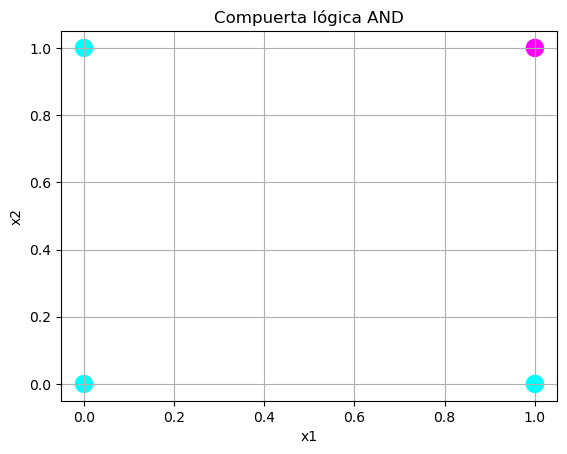

In [3]:
#Visualizar los datos
plt.scatter(entradas[:,0], entradas[:,1], c=etiquetas, cmap='cool', marker='o', label='Datos de entrada', s=150)

plt.title('Compuerta lógica AND')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

plt.show()

In [4]:
tasa_aprendizaje = 0.045  # Define la tasa de aprendizaje utilizada para ajustar el modelo
iteraciones = 20          # Establece la cantidad de iteraciones que realizará el algoritmo

In [5]:
def activacion(z):
    # Función de activación escalón.
    # Si z es mayor que 0, devuelve 1; de lo contrario, devuelve 0.
    return 1 if z > 0 else 0


def predecir(entradas, pesos, umbral):
    # Calculamos la suma ponderada de las entradas más el umbral.
    z = np.dot(entradas, pesos) + umbral

    # Aplicamos la función de activación para obtener la predicción.
    return activacion(z)


def train(entradas, etiquetas, tasa_aprendizaje, iteraciones):

    # Inicializamos aleatoriamente los pesos.
    # En este caso se generan 2 pesos porque tenemos 2 características de entrada.
    pesos = np.random.rand(2)

    # Inicializamos aleatoriamente el umbral.
    umbral = np.random.rand()

    # Mostramos los valores iniciales para poder observar cómo comienza el entrenamiento.
    print(f"Pesos iniciales {pesos}")
    print(f"Umbral inicial {umbral}")

    # Repetimos el proceso de entrenamiento la cantidad de veces indicada.
    for iteracion in range(iteraciones):
        print(f"Iteración {iteracion}")

        # Acumulamos los errores de todas las entradas de esta iteración.
        error_total = 0

        # Recorremos simultáneamente las entradas y sus etiquetas correctas.
        for entrada, etiqueta in zip(entradas, etiquetas):
            print(f"Entrada: {entrada}, etiqueta: {etiqueta}", end=" ")

            # Calculamos la suma ponderada:
            # z = entrada1 * peso1 + entrada2 * peso2 + umbral
            z = np.dot(entrada, pesos) + umbral

            # Obtenemos la predicción aplicando la función de activación.
            y = activacion(z)

            # Calculamos el error comparando la etiqueta correcta
            # con la predicción realizada por el perceptrón.
            error = etiqueta - y

            # Acumulamos el valor absoluto del error.
            error_total += abs(error)

            print(f"Error {error}")

            # Calculamos cuánto debemos modificar cada peso.
            # La actualización depende de:
            # - la tasa de aprendizaje
            # - el error cometido
            # - el valor de la entrada
            delta_w = tasa_aprendizaje * error * entrada

            # Actualizamos los pesos sumando la corrección calculada.
            pesos = pesos + delta_w

            # Calculamos cuánto debemos modificar el umbral.
            delta_b = tasa_aprendizaje * error

            # Actualizamos el umbral.
            umbral = umbral + delta_b

        # Calculamos el error promedio de la iteración.
        error_promedio = error_total / len(entradas)

        # Mostramos el error promedio para observar cómo aprende el modelo.
        print(f"Error promedio: {error_promedio}")

    # Al terminar el entrenamiento, devolvemos los pesos y el umbral aprendidos.
    return pesos, umbral


In [6]:
p, u = train(entradas, etiquetas, tasa_aprendizaje, iteraciones)


print(f"Pesos ajustados: {p}")
print(f"Umbral ajustado: {u}")

Pesos iniciales [0.77704225 0.87188512]
Umbral inicial 0.9484081091114863
Iteración 0
Entrada: [0 0], etiqueta: 0 Error -1
Entrada: [0 1], etiqueta: 0 Error -1
Entrada: [1 0], etiqueta: 0 Error -1
Entrada: [1 1], etiqueta: 1 Error 0
Error promedio: 0.75
Iteración 1
Entrada: [0 0], etiqueta: 0 Error -1
Entrada: [0 1], etiqueta: 0 Error -1
Entrada: [1 0], etiqueta: 0 Error -1
Entrada: [1 1], etiqueta: 1 Error 0
Error promedio: 0.75
Iteración 2
Entrada: [0 0], etiqueta: 0 Error -1
Entrada: [0 1], etiqueta: 0 Error -1
Entrada: [1 0], etiqueta: 0 Error -1
Entrada: [1 1], etiqueta: 1 Error 0
Error promedio: 0.75
Iteración 3
Entrada: [0 0], etiqueta: 0 Error -1
Entrada: [0 1], etiqueta: 0 Error -1
Entrada: [1 0], etiqueta: 0 Error -1
Entrada: [1 1], etiqueta: 1 Error 0
Error promedio: 0.75
Iteración 4
Entrada: [0 0], etiqueta: 0 Error -1
Entrada: [0 1], etiqueta: 0 Error -1
Entrada: [1 0], etiqueta: 0 Error -1
Entrada: [1 1], etiqueta: 1 Error 0
Error promedio: 0.75
Iteración 5
Entrada: [0 0]

In [7]:
predecir([1, 1], p, u)

1

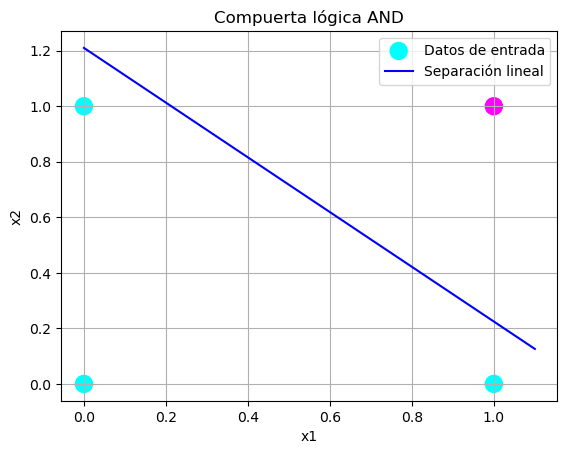

In [8]:
#Visualizar los datos
plt.scatter(entradas[:,0], entradas[:,1], c=etiquetas, cmap='cool', marker='o', label='Datos de entrada', s=150)

plt.title('Compuerta lógica AND')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)

#Linea de separacion
x_values = np.linspace(0, 1.1, 100)
y_values = (-p[0] / p[1]) * x_values - u / p[1]
plt.plot(x_values, y_values, '-b', label='Separación lineal')

plt.legend()
plt.show()

### Perceptron con Ski Learn

In [9]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [10]:
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

#Visualizamos las primeras cinco filas
data_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
data_df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [12]:
data_df.shape

(150, 5)

In [13]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [14]:
#Seleccionar columnas
columns = ["sepal length (cm)", "petal length (cm)", "target"]
data_df = data_df[columns]

#Filtrar las clases a utilizar
data_df = data_df[data_df["target"].isin([0,1])]

data_df.tail(5)

,sepal length (cm),petal length (cm),target
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1
99,5.7,4.1,1


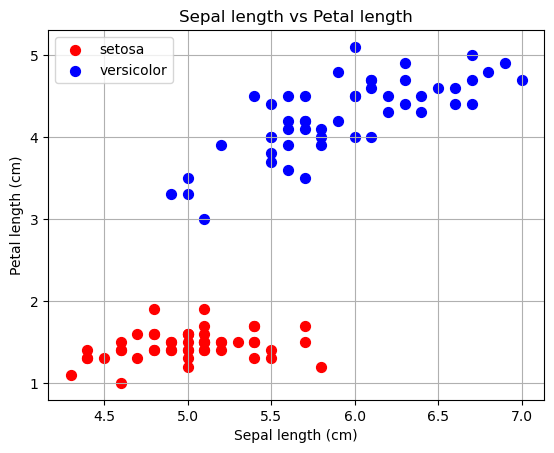

In [15]:
#Visualizar datos
plt.figure()

#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]

#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.grid()
plt.legend()
plt.show()

In [16]:
X = data_df[["sepal length (cm)", "petal length (cm)"]].values
#print(X)

y = data_df["target"].values 
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


#### Entrenamiento del Modelo

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [18]:
#Inicializar y entrenar el Perceptron
perceptron = Perceptron(max_iter=10, eta0=0.05)
perceptron.fit(X_train, y_train)

Perceptron(eta0=0.05, max_iter=10)

In [19]:
#Obtener pesos y sesgo
pesos = perceptron.coef_[0]
sesgo = perceptron.intercept_[0]
print(f'Pesos: {pesos}')
print(f'Sesgo: {sesgo}')

Pesos: [-0.165  0.31 ]
Sesgo: -0.05


In [20]:
#Predecir los datos del conjunto de prueba
y = perceptron.predict(X_test)

In [21]:
print(y)

[1 1 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 0]


In [22]:
print(y_test)

[1 1 1 0 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 0]


In [23]:
print(perceptron.predict(np.array([6.2, 4.3]).reshape(1, -1)))

print(perceptron.predict([[6.2, 4.3]]))

[1]
[1]


In [24]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y, y_test)
print(f'Exactitud del perceptron: {accuracy:.2f}')

Exactitud del perceptron: 1.00


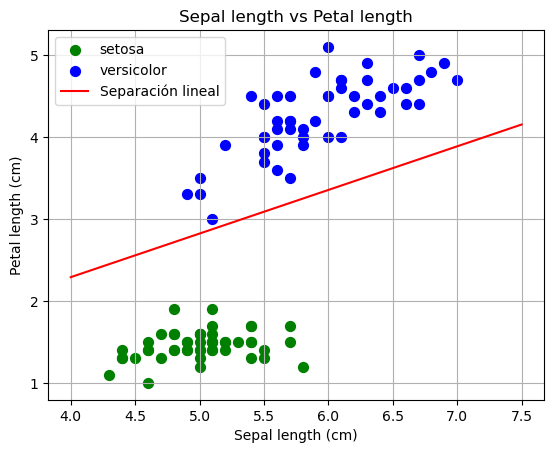

In [25]:
#Visualizar datos
plt.figure()

#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]

#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="green", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)

x_values = np.linspace(4, 7.5, 100)
y_values = (-pesos[0] / pesos[1]) * x_values - sesgo / pesos[1]
plt.plot(x_values, y_values, '-r', label='Separación lineal')

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.grid()
plt.legend()
plt.show()

### Perceptron Multicapa

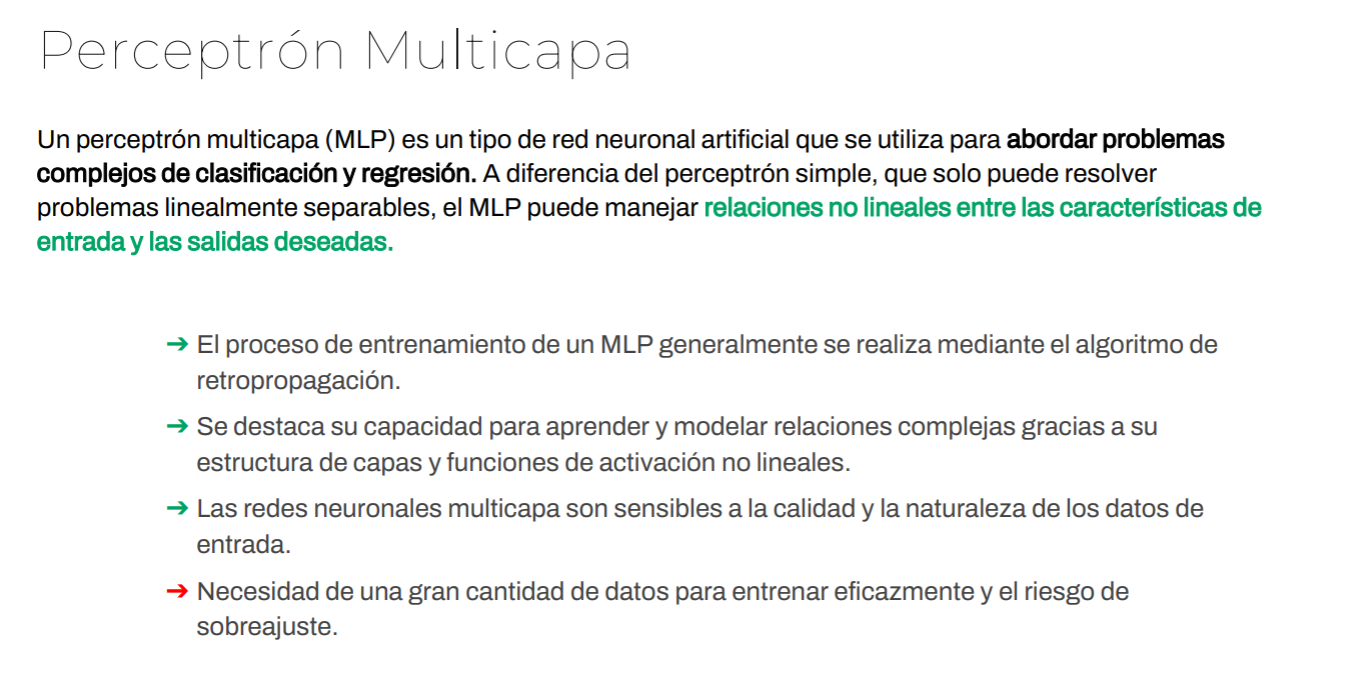

#### Perceptron Multicapa con Regresion

In [26]:
#Cargar el dataset
california = fetch_california_housing()

#Leer el dataset
data_house = pd.DataFrame(california.data, columns= california.feature_names)
data_house.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [27]:
data_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [28]:
data_house["MedHouseVal"] = california.target

In [29]:
data_house.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [30]:
data_house.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

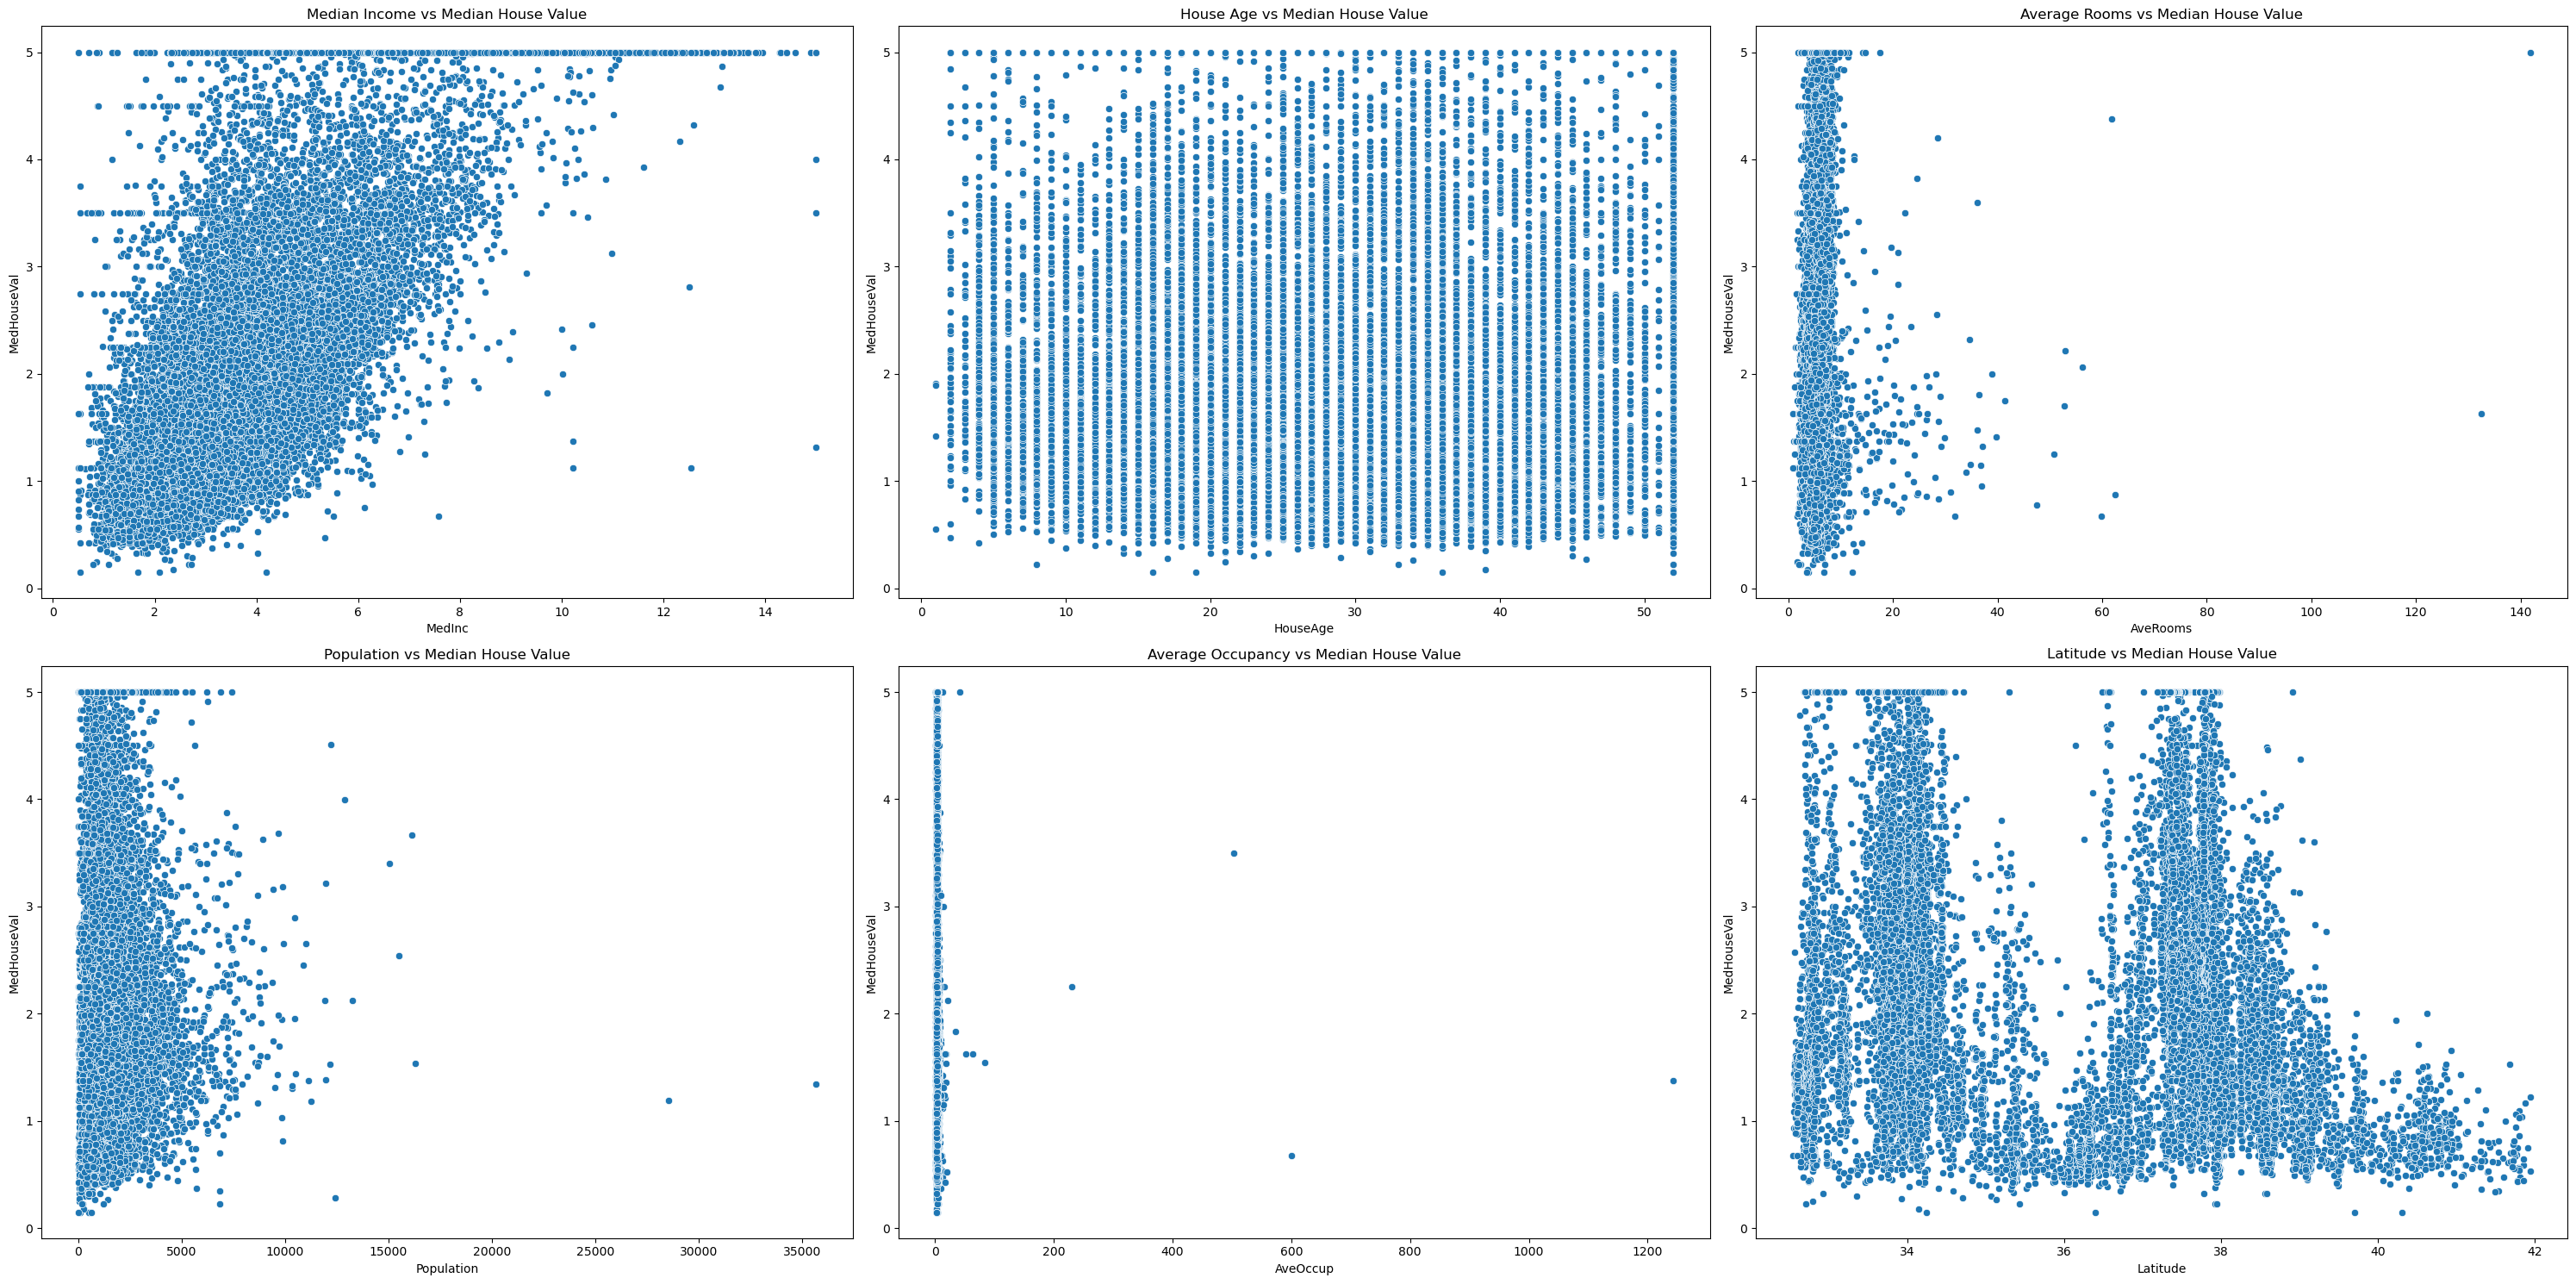

In [31]:
# Graficar algunas características contra el valor de la vivienda
plt.figure(figsize=(30, 15))

plt.subplot(2, 3, 1)
sns.scatterplot(x='MedInc', y='MedHouseVal', data=data_house)
plt.title('Median Income vs Median House Value')

plt.subplot(2, 3, 2)
sns.scatterplot(x='HouseAge', y='MedHouseVal', data=data_house)
plt.title('House Age vs Median House Value')

plt.subplot(2, 3, 3)
sns.scatterplot(x='AveRooms', y='MedHouseVal', data=data_house)
plt.title('Average Rooms vs Median House Value')

plt.subplot(2, 3, 4)
sns.scatterplot(x='Population', y='MedHouseVal', data=data_house)
plt.title('Population vs Median House Value')

plt.subplot(2, 3, 5)
sns.scatterplot(x='AveOccup', y='MedHouseVal', data=data_house)
plt.title('Average Occupancy vs Median House Value')

plt.subplot(2, 3, 6)
sns.scatterplot(x='Latitude', y='MedHouseVal', data=data_house)
plt.title('Latitude vs Median House Value')

plt.tight_layout()
plt.show()

##### Division y Preentrenamiento

In [32]:
X = data_house[["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]].values

In [33]:
print(X)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [34]:
y = data_house["MedHouseVal"].values

In [35]:
print(y)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [36]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train

array([[   3.2596    ,   33.        ,    5.0176565 , ...,    3.6918138 ,
          32.71      , -117.03      ],
       [   3.8125    ,   49.        ,    4.47354497, ...,    1.73809524,
          33.77      , -118.16      ],
       [   4.1563    ,    4.        ,    5.64583333, ...,    2.72321429,
          34.66      , -120.48      ],
       ...,
       [   2.9344    ,   36.        ,    3.98671727, ...,    3.33206831,
          34.03      , -118.38      ],
       [   5.7192    ,   15.        ,    6.39534884, ...,    3.17889088,
          37.58      , -121.96      ],
       [   2.5755    ,   52.        ,    3.40257649, ...,    2.10869565,
          37.77      , -122.42      ]])

In [38]:
y_train

array([1.03 , 3.821, 1.726, ..., 2.221, 2.835, 3.25 ])

In [39]:
# Creamos un objeto StandardScaler para estandarizar los datos
scaler = StandardScaler()

# Calculamos la media y la desviación estándar usando SOLO los datos de entrenamiento
# y luego transformamos X_train.
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos al conjunto de prueba la misma transformación aprendida
# a partir de X_train.
X_test_scaled = scaler.transform(X_test)

# Mostramos los datos de prueba originales, antes de estandarizarlos
print(X_test)

# Mostramos los datos de prueba después de la estandarización
print(X_test_scaled)

[[   1.6812       25.            4.19220056 ...    3.87743733
    36.06       -119.01      ]
 [   2.5313       30.            5.03938356 ...    2.67979452
    35.14       -119.46      ]
 [   3.4801       52.            3.97715472 ...    1.36033229
    37.8        -122.44      ]
 ...
 [   9.2298       25.            7.23767606 ...    2.79049296
    37.31       -122.05      ]
 [   2.785        36.            5.28902954 ...    2.58860759
    36.77       -119.76      ]
 [   3.5521       17.            3.98883929 ...    3.72991071
    34.22       -118.37      ]]
[[-1.15508475 -0.28632369 -0.52068576 ...  0.06740798  0.1951
   0.28534728]
 [-0.70865905  0.11043502 -0.16581537 ... -0.03602975 -0.23549054
   0.06097472]
 [-0.21040155  1.85617335 -0.61076476 ... -0.14998876  1.00947776
  -1.42487026]
 ...
 [ 2.80902421 -0.28632369  0.75501156 ... -0.02646898  0.78014149
  -1.23041404]
 [-0.57542978  0.58654547 -0.06124296 ... -0.04390537  0.52740357
  -0.08860699]
 [-0.17259111 -0.92113763 -0.6

In [40]:
# Creamos el modelo de red neuronal MLP (Multi-Layer Perceptron)
# para realizar una tarea de regresión.
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 100),  # Dos capas ocultas, con 100 neuronas cada una
    max_iter=1000,                  # Máximo de 1000 iteraciones durante el entrenamiento
    alpha=0.001,                    # Parámetro de regularización para evitar sobreajuste
    random_state=42                 # Semilla para obtener resultados reproducibles
)

# Entrenamos el modelo utilizando los datos de entrenamiento estandarizados
# y sus valores objetivo correspondientes.
mlp.fit(X_train_scaled, y_train)


MLPRegressor(alpha=0.001, hidden_layer_sizes=(100, 100), max_iter=1000,
             random_state=42)

In [41]:
#Realizar predicciones con los datos de prueba
y_pred = mlp.predict(X_test_scaled)

In [42]:
print(y_pred)

[0.5938684  0.72094619 5.26028703 ... 4.96146647 0.72184717 1.97399288]


In [43]:
print(y_test)

[0.477   0.458   5.00001 ... 5.00001 0.723   1.515  ]


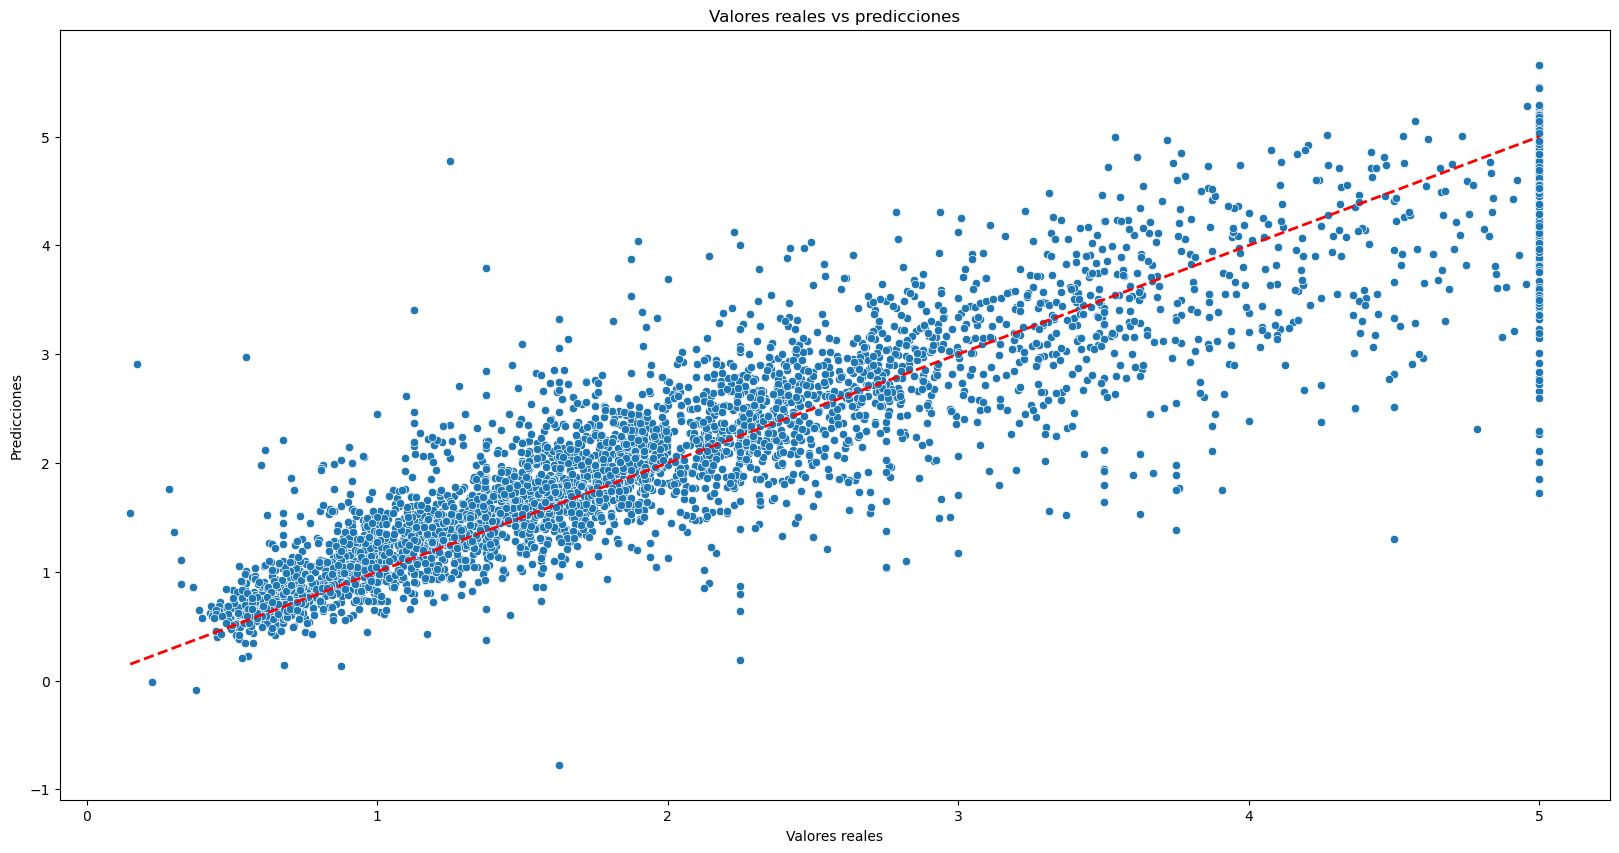

In [44]:
plt.figure(figsize=(20, 10))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs predicciones")
plt.show()

In [45]:
# Evaluar el rendimiento del modelo

# Calculamos el Error Cuadrático Medio (MSE).
# Cuanto más cercano a 0, menor es el error.
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")


# Calculamos el coeficiente de determinación R².
# Un valor cercano a 1 indica un buen ajuste del modelo.
r2 = r2_score(y_test, y_pred)
print(f"R2: {r2:.2f}")


# Calculamos el MAPE (Error Porcentual Absoluto Medio).
# Indica en promedio qué porcentaje se alejan las predicciones
# respecto a los valores reales.
mape = mean_absolute_percentage_error(y_test, y_pred)

# Convertimos el resultado a porcentaje multiplicándolo por 100.
mape_porcentaje = mape * 100

print(f"MAPE: {mape_porcentaje:.2f}%")


MSE: 0.26
R2: 0.80
MAPE: 20.40%


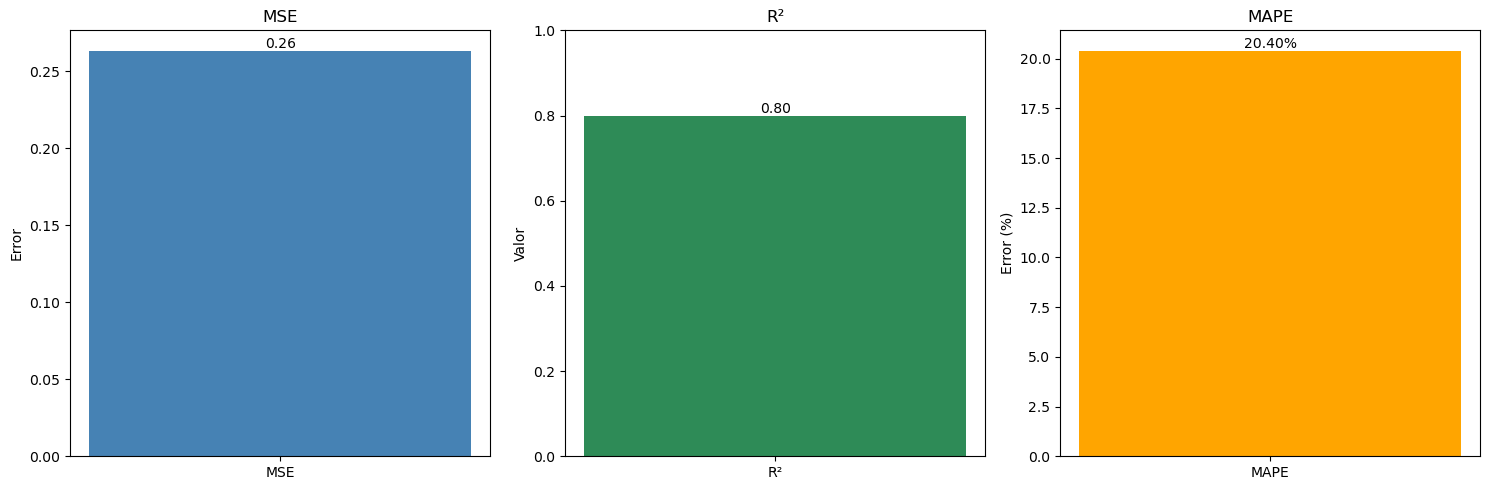

In [46]:
# Creamos una figura con tres gráficos
fig, ax = plt.subplots(1, 3, figsize=(15, 5))


# Gráfico del MSE
ax[0].bar(["MSE"], [mse], color="steelblue")
ax[0].text(0, mse, f"{mse:.2f}", ha="center", va="bottom")
ax[0].set_title("MSE")
ax[0].set_ylabel("Error")


# Gráfico del R²
ax[1].bar(["R²"], [r2], color="seagreen")
ax[1].text(0, r2, f"{r2:.2f}", ha="center", va="bottom")
ax[1].set_title("R²")
ax[1].set_ylabel("Valor")
ax[1].set_ylim(0, 1)


# Gráfico del MAPE
ax[2].bar(["MAPE"], [mape_porcentaje], color="orange")
ax[2].text(0, mape_porcentaje, f"{mape_porcentaje:.2f}%",
           ha="center", va="bottom")
ax[2].set_title("MAPE")
ax[2].set_ylabel("Error (%)")


# Ajustamos los espacios entre los gráficos
plt.tight_layout()

# Mostramos los gráficos
plt.show()

##### Conclusion

A partir de los resultados obtenidos, se puede concluir que el modelo de red neuronal MLPRegressor presenta un rendimiento adecuado para realizar las predicciones. El MSE de 0.26 indica que el error cuadrático medio de las predicciones es relativamente bajo, mientras que el R² de 0.80 muestra que el modelo logra explicar aproximadamente el 80 % de la variabilidad de los datos.

Por otro lado, el MAPE de 20.40 % indica que las predicciones presentan, en promedio, un error porcentual absoluto cercano al 20 %. Si bien este valor muestra que existe cierto margen de error, el modelo consigue realizar predicciones razonablemente buenas.

En conjunto, los resultados muestran que el modelo tiene un buen nivel de capacidad predictiva, aunque todavía existe margen para mejorar su precisión mediante ajustes en la arquitectura de la red neuronal, los parámetros de entrenamiento o el preprocesamiento de los datos.